# Description
Calculation of the number of passes using real breadcrumbs. Finished on May 18th, 2026. It is the first version it can count by boundary cell. The grid is done by rectangles

In [12]:
%load_ext autoreload
%autoreload 2
%reset -f
%matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
from locallib.picarrodb import *
from locallib.query import *
from locallib.box import *
from locallib.query import *

from NOP import *

import matplotlib.pyplot as plt
from shapely import wkt


# Configuration

# Query the surveys

In [14]:
a = get_reports('Cadent',years = [2026]).execute([EU2_Conn])
report_bc = a.iloc[[700]].copy()
#report_bc.to_csv('Reports_used.csv', mode='a', header=False, index=False)
report_bc.db.set_query(query_Segments_byReport(report_table = '#TempReport'))
segments = report_bc.db.execute([EU2_Conn], source_col = 'ReportId', temp_table_name = '#TempReport')
# Create a GeoDataFrame for the segments with geometry from the Breadcrumb column
segments['geometry'] = segments['Breadcrumb'].apply(wkt.loads)
segments_gdf = gpd.GeoDataFrame(segments, geometry='geometry', crs='EPSG:4326')


In [15]:
# Get the unique SurveyIds from the segments DataFrame
survey_ids = pd.DataFrame(segments['SurveyId'].unique(), columns=['SurveyId'])
survey_ids.db.set_query(f"SELECT SA.SurveyId, Shape.STAsText() as SurveyAreaBoundary FROM SurveyArea SA WHERE SA.SurveyId IN (SELECT SurveyId FROM #TempSurveys)")
s = survey_ids.db.execute(EU2_Conn, source_col = 'SurveyId', temp_table_name = '#TempSurveys')

In [16]:
s['geometry'] = s['SurveyAreaBoundary'].apply(wkt.loads)
s_gdf = gpd.GeoDataFrame(s, geometry='geometry', crs='EPSG:4326')

In [17]:
# Get the segments for each survey (as a list of DataFrames)
segments_per_survey = [df for _, df in segments.groupby('SurveyId')]
output = []
surveys = []

survey_gdf = segments_per_survey[0].copy()
survey_gdf['geometry'] = survey_gdf['Breadcrumb'].apply(wkt.loads)
survey_gdf = gpd.GeoDataFrame(survey_gdf, geometry='geometry', crs='EPSG:4326')
utm_crs = survey_gdf.estimate_utm_crs()
survey_gdf = survey_gdf.to_crs(utm_crs)
survey_gdf.set_geometry('geometry', inplace=True)
surveys.append(survey_gdf)
survey_gdf.nop.prepare_survey_gdf()
cell = survey_gdf.nop.generate_grid()
net = survey_gdf.nop.create_network()


Center of the bounds: POINT (656870.83446 5938950.94847)
Processing angle:  0
Processing angle:  -10.0
Processing angle:  -20.0
Processing angle:  -30.0
Processing angle:  -40.0
Processing angle:  -50.0
Processing angle:  -60.0
Processing angle:  -70.0
Processing angle:  -80.0
Processing angle:  -90.0
Processing angle:  -100.0
Processing angle:  -110.0
Processing angle:  -120.0
Processing angle:  -130.0
Processing angle:  -140.0
Processing angle:  -150.0
Processing angle:  -160.0
Processing angle:  -170.0
Processing angle:  -180.0
Total boundaries: 2420
Boundaries with no NaN 'nop': 2386
Boundaries after length and spread filters: 2090
Boundaries after removing overlaps: 1581
Boundaries after removing close together cells: 1546
1546 splitters -> 1527 cells
Created network with 1527 nodes and 1547 edges.


In [18]:
s_gdf = survey_gdf.nop.survey_gdf
cell_gdf = survey_gdf.nop.cell_gdf

In [19]:
s_gdf.sort_values(by = 'Order', inplace = True)
s_gdf

,ReportId,SurveyId,Breadcrumb,Order,geometry
562,2C524C2E-2EB2-C1EC-338D-3A209D084883,3BE5CB90-9B33-1B54-7078-3A2096909834,"LINESTRING (-0.61653662 53.56632179, -0.616571...",1,"LINESTRING (970.050 -1036.778, 967.250 -1022.9..."
457,2C524C2E-2EB2-C1EC-338D-3A209D084883,3BE5CB90-9B33-1B54-7078-3A2096909834,"LINESTRING (-0.61410003 53.56621626, -0.611330...",2,"LINESTRING (1131.775 -1043.110, 1317.886 -1117..."
500,2C524C2E-2EB2-C1EC-338D-3A209D084883,3BE5CB90-9B33-1B54-7078-3A2096909834,"LINESTRING (-0.61133017 53.56548965, -0.608609...",3,"LINESTRING (1317.886 -1117.775, 1500.940 -1198..."
463,2C524C2E-2EB2-C1EC-338D-3A209D084883,3BE5CB90-9B33-1B54-7078-3A2096909834,"LINESTRING (-0.60860966 53.56470814, -0.608044...",4,"LINESTRING (1500.940 -1198.649, 1538.938 -1213..."
529,2C524C2E-2EB2-C1EC-338D-3A209D084883,3BE5CB90-9B33-1B54-7078-3A2096909834,"LINESTRING (-0.6154689 53.56630425, -0.6156771...",5,"LINESTRING (1040.811 -1036.361, 1027.020 -1036..."
...,...,...,...,...,...
375,2C524C2E-2EB2-C1EC-338D-3A209D084883,3BE5CB90-9B33-1B54-7078-3A2096909834,"LINESTRING (-0.64865291 53.58459374, -0.648368...",193,"LINESTRING (-1223.591 924.787, -1204.568 920.0..."
566,2C524C2E-2EB2-C1EC-338D-3A209D084883,3BE5CB90-9B33-1B54-7078-3A2096909834,"LINESTRING (-0.64562358 53.5846962, -0.6440570...",194,"LINESTRING (-1023.475 942.813, -919.313 931.63..."
510,2C524C2E-2EB2-C1EC-338D-3A209D084883,3BE5CB90-9B33-1B54-7078-3A2096909834,"LINESTRING (-0.64258068 53.58465739, -0.641342...",195,"LINESTRING (-821.942 945.164, -740.310 957.270..."
559,2C524C2E-2EB2-C1EC-338D-3A209D084883,3BE5CB90-9B33-1B54-7078-3A2096909834,"LINESTRING (-0.63955339 53.5847632, -0.6379979...",196,"LINESTRING (-621.975 963.574, -518.967 965.101..."


In [20]:
# Efficiently concatenate the LineStrings based on 'Order'
ordered_geoms = s_gdf.sort_values('Order')['geometry'].values
all_coords = []
for geom in ordered_geoms:
    if not all_coords:
        all_coords.extend(geom.coords)
    else:
        # drop the first point if it's a duplicate of previous segment's last point
        coords = list(geom.coords)
        if coords[0] == all_coords[-1]:
            coords = coords[1:]
        all_coords.extend(coords)
total_linestring = LineString(all_coords)

In [21]:
total_gdf = gpd.GeoDataFrame([{'geometry': total_linestring}], crs=s_gdf.crs)

In [ ]:
# Clip each breadcrumb to cells (avoids splitting at road intersections)
survey_cell = survey_gdf.nop.intersect_survey_with_cells(cell_gdf)
nop = (
    survey_cell.groupby("cell_idx")["Order"]
    .nunique()
    .reset_index(name="n_passes")
)


In [ ]:
survey_cell_904 = survey_cell[survey_cell["cell_idx"] == 904]
num_lines = count_survey_passes(survey_cell_904)
print(f"Number of lines in cell 904: {num_lines}")


Number of lines in cell 904: 3


In [24]:
total_gdf

,geometry
0,"LINESTRING (970.050 -1036.778, 967.250 -1022.9..."


<Axes: >

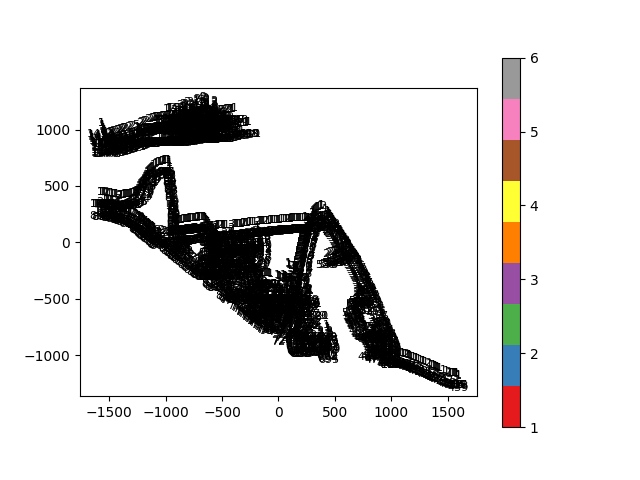

In [25]:
cell_wnop = cell_gdf.merge(nop, on='cell_idx', how='left')
cell_wnop['n_passes'] = cell_wnop['n_passes'].fillna(0)
ax = cell_wnop.plot(column='n_passes', cmap='Set1', legend=True)
for idx, row in cell_wnop.iterrows():
    if row['geometry'].geom_type == 'Polygon':
        x, y = row['geometry'].centroid.x, row['geometry'].centroid.y
        ax.text(x, y, f"{int(row['n_passes'])}\n{row['cell_idx']}", ha='center', va='center', fontsize=8, color='black')
s_gdf.plot(ax = ax, color = 'white')

In [30]:
cell_wnop[cell_wnop.index == 542]

,cell_idx,geometry,n_passes
542,542,"POLYGON ((330.658 185.403, 344.060 185.009, 35...",3


In [ ]:
survey_cell[survey_cell['cell_idx'] == 542]

,cell_idx,Order,geometry
765,542,28,"LINESTRING (330.658 180.401, 344.237 180.002)"
766,542,29,"LINESTRING (344.237 180.002, 354.708 181.052)"
767,542,29,"LINESTRING (354.748 180.825, 339.858 179.384)"
768,542,30,"LINESTRING (339.858 179.384, 330.658 178.567)"


In [29]:
survey_cell_904 = survey_cell[survey_cell["cell_idx"] == 904]
count_survey_passes(survey_cell_904)


,cell_idx,Order,geometry
1584,904,134,"LINESTRING (-894.450 52.551, -864.744 57.188)"
1585,904,136,"LINESTRING (-864.700 56.939, -873.945 55.537, ..."
1586,904,137,"LINESTRING (-883.109 30.060, -883.718 42.808, ..."
